# P3 — Case-study panels

Two figures that carry most of the story of the paper:

1. **GBPUSD/EURUSD — August 2024.**  The only month where the HMM kill-switch
   meaningfully helps:  AR damps a directional drift the symmetric z-score rule
   would otherwise fight.  Even so, **BuyHold remains the real winner**.
2. **EURNOK/EURSEK — August 2025.**  A 'damning negative control':  BuyHold is
   solidly positive while all three traded strategies bleed bps fighting drift.

Each panel stacks: spread level + BuyHold cum PnL  →  smoothed Danger probability
 →  cumulative PnL of all four strategies  →  position heatmap.

Outputs:  `code/plots/eda/case_gbpeur_aug24.pdf`  and  `case_noksek_aug25.pdf`.

In [1]:
import os, sys
if os.path.exists('/content'):
    os.system('curl -sL https://raw.githubusercontent.com/egil10/stk-mat2011/main/code/scripts/colab.py -o /content/colab.py')
    sys.path.insert(0, '/content')
    from colab import setup; setup('code/visualisations')
else:
    sys.path.insert(0, '../scripts')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD           : /content/stk-mat2011/code/visualisations
Scripts path  : /content/stk-mat2011/code/scripts
Data symlink  : /content/stk-mat2011/code/data/processed -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet files : 916


In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from month    import MONTH
from plotting import apply_econ_style, ECON, save_figure_pdf
apply_econ_style()

In [3]:
# Run only the two months we need (≈30s each on a modern laptop)
m_gbp = MONTH('GBPUSD', 'EURUSD', save_plots=False)
m_gbp.run_months(['202408'])

m_nok = MONTH('EURNOK', 'EURSEK', save_plots=False)
m_nok.run_months(['202508'])

Engine: train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
[2024-08-19] skipped: Steady-state probabilities could not be constructed.
202408  bars=3,470  days=22  | Sharpe  B= -0.49  AR=+23.53  MS= +4.39
Engine: train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
202508  bars=2,886  days=21  | Sharpe  B=-43.35  AR=-54.48  MS=-31.45


,Baseline_Sharpe,Baseline_PnLbps,Baseline_Trades,AR_Sharpe,AR_PnLbps,AR_Trades,MS_AR_Sharpe,MS_AR_PnLbps,MS_AR_Trades
Month,,,,,,,,,
202508,-43.354248,-664.874171,95,-54.48086,-255.468151,29,-31.448038,-349.362378,44


Saved plot PDF: ../plots/eda/case_gbpeur_aug24.pdf


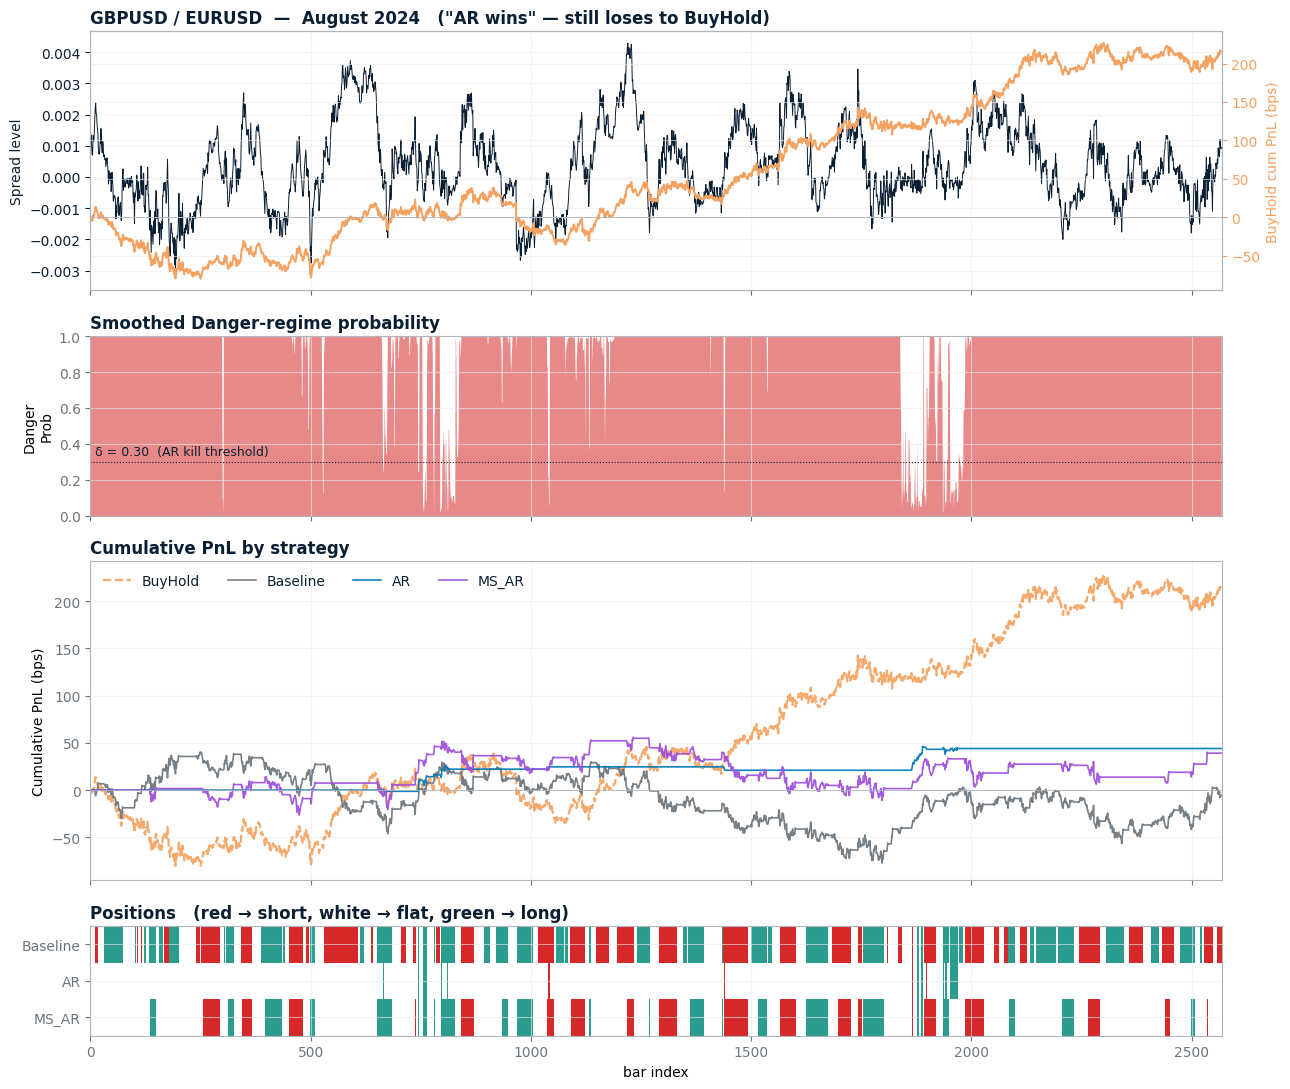

Saved plot PDF: ../plots/eda/case_noksek_aug25.pdf


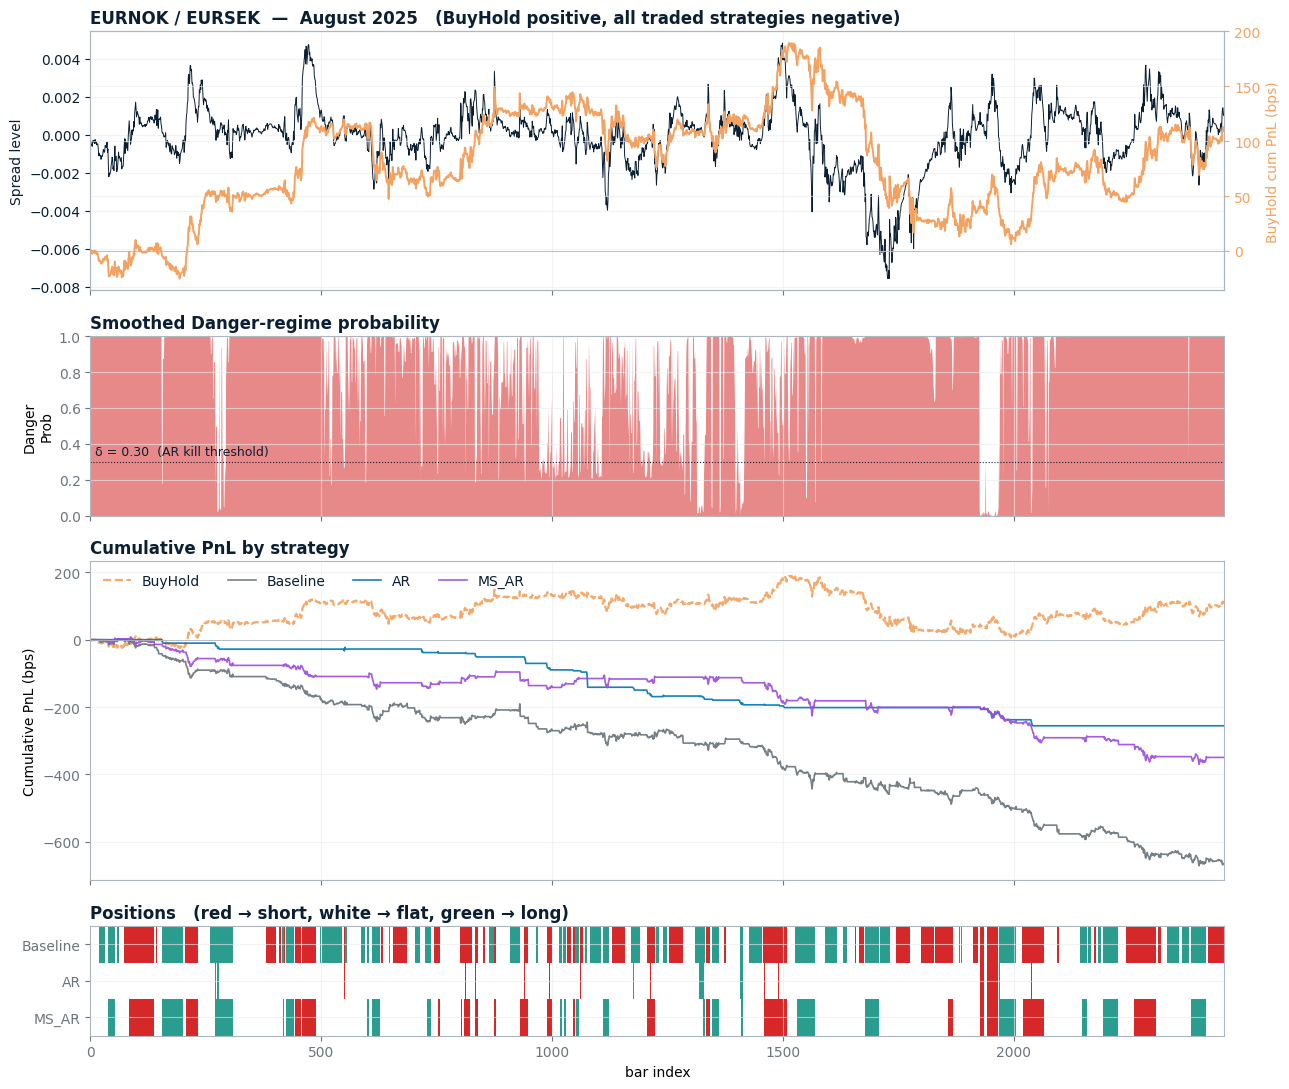

In [4]:
STRATS   = ['BuyHold', 'Baseline', 'AR', 'MS_AR']
PALETTE  = {s: ECON[s] for s in STRATS}
LINESTYL = {'BuyHold': '--', 'Baseline': '-', 'AR': '-', 'MS_AR': '-'}

POS_CMAP = mcolors.ListedColormap([ECON['red'], '#FFFFFF', ECON['green']])
POS_NORM = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], POS_CMAP.N)

def case_study(results, *, title, filename):
    n      = len(results)
    x      = np.arange(n)
    spread = results['Spread_Level'].values
    danger = results['Danger_Regime_Prob'].rolling(3).median().bfill().values
    bh_bps = results['CumReturn_BuyHold'].values * 1e4

    fig, axes = plt.subplots(
        4, 1, figsize=(13, 11), sharex=True,
        gridspec_kw={'height_ratios': [1.3, 0.9, 1.6, 0.55]},
    )

    # Panel 1 — spread level (left) + BuyHold cumulative PnL (right)
    ax = axes[0]
    ax.plot(x, spread, color=ECON['navy'], lw=0.7, label='Spread level')
    ax.set_ylabel('Spread level', color=ECON['navy'])
    ax.tick_params(axis='y', colors=ECON['navy'])
    ax2 = ax.twinx()
    ax2.plot(x, bh_bps, color=ECON['BuyHold'], lw=1.4)
    ax2.set_ylabel('BuyHold cum PnL (bps)', color=ECON['BuyHold'])
    ax2.tick_params(axis='y', colors=ECON['BuyHold'])
    ax2.axhline(0, color=ECON['lt_grey'], lw=0.6)
    ax.set_title(title, loc='left', fontweight='bold')

    # Panel 2 — smoothed Danger probability
    ax = axes[1]
    ax.fill_between(x, 0, danger, color=ECON['red'], alpha=0.55, lw=0)
    ax.axhline(0.30, color=ECON['navy'], lw=0.8, ls=':')
    ax.text(10, 0.34, 'δ = 0.30  (AR kill threshold)', fontsize=9, color=ECON['navy'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('Danger\nProb')
    ax.set_title('Smoothed Danger-regime probability', loc='left', fontweight='bold')

    # Panel 3 — cumulative PnL by strategy
    ax = axes[2]
    for s in STRATS:
        y = results[f'CumReturn_{s}'].values * 1e4
        ax.plot(x, y, color=PALETTE[s], ls=LINESTYL[s],
                lw=1.6 if s == 'BuyHold' else 1.2, alpha=0.92, label=s)
    ax.axhline(0, color=ECON['lt_grey'], lw=0.6)
    ax.set_ylabel('Cumulative PnL (bps)')
    ax.legend(loc='upper left', ncol=4, frameon=False)
    ax.set_title('Cumulative PnL by strategy', loc='left', fontweight='bold')

    # Panel 4 — position heatmap for the three traded strategies
    ax = axes[3]
    traded = ['Baseline', 'AR', 'MS_AR']
    heat   = np.vstack([results[f'Target_{s}'].values for s in traded])
    ax.imshow(heat, aspect='auto', cmap=POS_CMAP, norm=POS_NORM,
              interpolation='nearest', extent=[0, n, len(traded), 0])
    ax.set_yticks(np.arange(len(traded)) + 0.5)
    ax.set_yticklabels(traded)
    ax.set_xlabel('bar index')
    ax.set_title('Positions   (red → short, white → flat, green → long)',
                 loc='left', fontweight='bold')

    plt.tight_layout()
    save_figure_pdf(fig, filename, pdf_dir='../plots/eda', enabled=True, verbose=True)
    plt.show()

# Build the two panels
case_study(
    m_gbp.runs['202408'][0],
    title='GBPUSD / EURUSD  —  August 2024   ("AR wins" — still loses to BuyHold)',
    filename='case_gbpeur_aug24.pdf',
)
case_study(
    m_nok.runs['202508'][0],
    title='EURNOK / EURSEK  —  August 2025   (BuyHold positive, all traded strategies negative)',
    filename='case_noksek_aug25.pdf',
)